# **Experimentos y análisis de algoritmos de ordenamiento**
## **Alumno: Isaac Hernández Ramírez**

# Introducción:

El análisis de los algoritmos de ordenamiento es fundamental en la informática y en nuestro campo de estudio actual (ciencia de datos), ya que su eficiencia afecta directamente el desempeño de diversas aplicaciones. En este notebook implementamos y hacemos comparacion del rendimiento de diferentes algoritmos de ordenamiento:

- Heapsort

- Mergesort

- Quicksort

- Bubblesort

- SkipList (estructura de datos probabilística)

Usaremos conjuntos de datos con diferentes niveles de desorden para medir el número de comparaciones y el tiempo de ejecución.

El estudio de algoritmos eficientes de ordenamiento ha sido un tema recurrente en la últimas prácticas. Pugh (1990) introdujo las Skip Lists como una alternativa probabilística a los árboles balanceados, ofreciendo una complejidad promedio de O(n log n). Cook y Kim (1980) analizaron los mejores algoritmos para listas casi ordenadas, lo cual es relevante al evaluar el rendimiento de diferentes estrategias de ordenamiento según el grado de desorden. Estivill-Castro y Wood (1992) realizaron un amplio estudio sobre algoritmos adaptativos de ordenamiento, lo que permite entender cuáles estrategias funcionan mejor en distintos escenarios.

## ✅ Importación de librerías

In [ ]:
import random
import time
import copy
import zipfile
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## ✅ Implementación de los algoritmos de ordenamiento

* En esta sección se implementan los algoritmos clásicos de ordenamiento: BubbleSort, QuickSort, MergeSort y HeapSort.  

* Cada uno se define como un método estático dentro de una clase contenedora (`SortingAlgorithms`) para mantener la organización modular.

* Además de ordenar, cada algoritmo cuenta las comparaciones realizadas, lo que permite evaluar su eficiencia más allá del tiempo de ejecución.

* Las implementaciones son estándar, pero se adaptan para registrar estadísticas útiles para el análisis experimental posterior.


In [ ]:
class SortingAlgorithms:

  #Ordenamiento burbuja
    @staticmethod
    def bubblesort(arr):
        comparaciones = 0  # Aquí está un contador de las comparaciones
        n = len(arr)
        arr = arr.copy()  # Trabajar en una copia para evitar modificar los datos originales
        for i in range(n):
            for j in range(0, n - i - 1):
                comparaciones += 1
                if arr[j] > arr[j + 1]:  # Comparar elementos adyacentes
                    arr[j], arr[j + 1] = arr[j + 1], arr[j]  # Intercambiar si están en el orden incorrecto
        return arr, comparaciones

    #Ordenamientos quick
    @staticmethod
    def quicksort(arr):
        comparaciones = [0]  # Usamos lista para rastrear comparaciones
        arr = arr.copy()

        def _partition(arr, low, high):
            #pivote = arr[high] ......... Cambiar
            pivot_index = random.randint(low, high) # Elegimos un pivote aleatorio
            arr[high], arr[pivot_index] = arr[pivot_index], arr[high]  
            pivote = arr[high] # Seleccionamos el pivote
            i = low - 1
            comps = 0  # contador

            for j in range(low, high):
                comps += 1
                if arr[j] <= pivote:
                    i += 1
                    arr[i], arr[j] = arr[j], arr[i]  # intercambiamos los elementos

            arr[i + 1], arr[high] = arr[high], arr[i + 1]  # ponemos el pivote en la posición correcta
            return i + 1, comps

        def _quicksort(arr, low, high):
            if low < high:
                pivot_idx, comps = _partition(arr, low, high)
                comparaciones[0] += comps
                _quicksort(arr, low, pivot_idx - 1)  # se ordena la sublista izquierda
                _quicksort(arr, pivot_idx + 1, high)  # se ordena la sublista derecha

        _quicksort(arr, 0, len(arr) - 1)
        return arr, comparaciones[0]

  #Ordenamientos merge
    @staticmethod
    def mergesort(arr):
        comparaciones = [0]
        arr = arr.copy()

        def _merge(left, right):
            resultado = []
            i = j = 0

            while i < len(left) and j < len(right):
                comparaciones[0] += 1  # incrementamos el contador de comparaciones
                if left[i] <= right[j]:
                    resultado.append(left[i])
                    i += 1
                else:
                    resultado.append(right[j])
                    j += 1

            resultado.extend(left[i:])  # ponemos los elementos restantes de la izquierda
            resultado.extend(right[j:])  # ponemos los elementos restantes de la derecha
            return resultado

        def _mergesort(arr):
            if len(arr) <= 1:
                return arr  # si el array tiene un solo elemento, ya está ordenado

            mid = len(arr) // 2  # encontramos el punto medio del array
            left = _mergesort(arr[:mid])  # ordenamos la mitad izquierda
            right = _mergesort(arr[mid:])  # ordenamos la mitad derecha

            return _merge(left, right)  # Combinar las dos mitades ordenadas

        sorted_arr = _mergesort(arr)
        return sorted_arr, comparaciones[0]


# Ordenamientos heap
    @staticmethod
    def heapsort(arr):
        comparaciones = 0
        arr = arr.copy()
        n = len(arr)

        def _heapify(arr, n, i):
            mayor = i  # inicializamoe le valor mayor como raíz
            izquierda = 2 * i + 1  # inicio izquierdo
            derecha = 2 * i + 2  # inicio derecho
            comps = 0

            if izquierda < n:
                comps += 1
                if arr[izquierda] > arr[mayor]:
                    mayor = izquierda

            if derecha < n:
                comps += 1
                if arr[derecha] > arr[mayor]:
                    mayor = derecha

            if mayor != i:
                arr[i], arr[mayor] = arr[mayor], arr[i]
                comps_more, _ = _heapify(arr, n, mayor)
                comps += comps_more

            return comps, arr

        # Construir el heap máximo
        for i in range(n // 2 - 1, -1, -1):
            comps, _ = _heapify(arr, n, i)
            comparaciones += comps

        # Extraer elementos uno por uno
        for i in range(n - 1, 0, -1):
            arr[0], arr[i] = arr[i], arr[0]
            comps, _ = _heapify(arr, i, 0)
            comparaciones += comps

        return arr, comparaciones


**Nota:**  
* El algoritmo Bubble Sort, en su forma básica como se implementa aquí, **no es adaptativo**, ya que siempre recorre todos los pares posibles incluso si la lista está parcialmente ordenada. Esto significa que realiza un número similar de comparaciones en todos los casos, manteniendo su complejidad O(n²). Algoritmos adaptativos ajustan su comportamiento según el grado de ordenamiento inicial, lo cual no sucede en este caso.


* La implementación estándar de Merge Sort utiliza **memoria adicional O(n)** para crear sublistas `left`, `right` y el array `resultado`. Aunque esta estrategia es eficiente en comparaciones y tiene una complejidad temporal de O(n log n), el uso de espacio adicional puede afectar el rendimiento en aplicaciones con grandes volúmenes de datos o restricciones de memoria.  
Existen versiones "in-place" de Merge Sort que reducen este uso de memoria, pero son más complejas y no siempre prácticas.


* Se actualizó la selección del pivote en QuickSort a una estrategia **aleatoria**, en lugar de usar siempre el último elemento. Esta mejora evita peores casos cuando el arreglo está ya ordenado o tiene patrones desfavorables, reduciendo la probabilidad de que el algoritmo degrade a O(n²). Esta modificación hace que el algoritmo sea más robusto y consistente en rendimiento.



## ✅Implementación de SkipList

* Aquí se implementa la estructura `SkipList`, una alternativa probabilística a las estructuras tradicionales de ordenamiento.  
* Su principio de funcionamiento se basa en listas enlazadas con niveles que permiten realizar búsquedas y ordenamientos con complejidad promedio O(n log n).  
* La clase incluye un método `sort()` que inserta los elementos en la estructura y devuelve la lista ordenada, además de contar las comparaciones realizadas.  
* Se emplea un nodo `header` con clave `-∞` como punto de partida, lo cual es una convención interna que no afecta los datos reales.  
* Esta estructura permite explorar el rendimiento de métodos menos convencionales frente a algoritmos deterministas.


In [ ]:
class Node:
    def __init__(self, key, level):
        self.key = key  # nodo
        self.forward = [None] * (level + 1)

class SkipList:
    def __init__(self, max_level=16, p=0.5):
        self.max_level = max_level
        self.p = p
        self.level = 0  # Nivel actual de la lista
        self.header = Node(-float('inf'), max_level)
        self.comparisons = 0  # Contador de comparaciones

    def random_level(self):
        lvl = 0
        while random.random() < self.p and lvl < self.max_level:
            lvl += 1
        return lvl

    def insert(self, key):
        update = [None] * (self.max_level + 1)  # arreglo para actualizar el puntero
        current = self.header

        for i in range(self.level, -1, -1):
            while current.forward[i] and current.forward[i].key < key:
                self.comparisons += 1  # incrementamos el contador de comparaciones
                current = current.forward[i]
            update[i] = current

        current = current.forward[0]

        if current and current.key == key:
            self.comparisons += 1  # incrementamos el contador de comparaciones
            return

        rlevel = self.random_level()

        if rlevel > self.level:
            for i in range(self.level + 1, rlevel + 1):
                update[i] = self.header
            self.level = rlevel

        new_node = Node(key, rlevel)  # creamos un nuevo nodo

        for i in range(rlevel + 1):
            new_node.forward[i] = update[i].forward[i]
            update[i].forward[i] = new_node

    def display_list(self):
        result = []
        node = self.header.forward[0]
        while node:
            result.append(node.key)
            node = node.forward[0]
        return result

    def sort(self, arr):
        self.comparisons = 0  # reiniciamos el contador
        arr = arr.copy()  # copia de datos
        for item in arr:
            self.insert(item)
        return self.display_list(), self.comparisons  # devolvemos la lista ordenada y el número de comparaciones

**Nota sobre el "ínfimo" en SkipList:**  
En versiones anteriores de este reporte usaba un valor artificial al que llamaba "ínfimo", lo cual no es necesario.

En esta versión, la implementación de `SkipList` **ya no utiliza ningún valor especial adicional** para inicializar o comparar.  
El único valor "especial" presente es `-float('inf')`, que se usa **solo** dentro del nodo `header` para representar el inicio de la lista.  
Este uso es una práctica común en estructuras como listas enlazadas o árboles, y **no interfiere con los datos reales ni con el modelo de comparación**.

De este modo, se corrige correctamente el uso innecesario del "ínfimo" mencionado en la retroalimentación.

## ✅ Funciones y visualización

* En esta función se automatiza la evaluación de los algoritmos de ordenamiento.  
* Se procesan múltiples archivos con listas de datos y, para cada uno, se ejecutan los algoritmos definidos, midiendo el número de comparaciones y el tiempo de ejecución.  
* Los resultados se almacenan y visualizan en gráficos comparativos para facilitar el análisis del rendimiento de cada método.


In [ ]:
# Funcion de llamada a los estaticos
def sort_algorithms(data_dict):
    algorithms = {
        'BubbleSort': SortingAlgorithms.bubblesort,
        'QuickSort': SortingAlgorithms.quicksort,
        'MergeSort': SortingAlgorithms.mergesort,
        'HeapSort': SortingAlgorithms.heapsort,
        'SkipList': lambda arr: SkipList().sort(arr)
    }

    results = {
        'Archivo': [],
        'Algoritmo': [],
        'Comparaciones': [],
        'Tiempos': []
    }

    for file_name, data in data_dict.items():
        print(f"Procesamos el archivo {file_name}")

        # Extraer la lista de la estructura del diccionario
        if isinstance(data, dict):
            # Obtener la primera clave en el diccionario (debería ser "reunion" o similar)
            if len(data) > 0:
                first_key = list(data.keys())[0]
                if isinstance(data[first_key], list):
                    data_to_sort = data[first_key]
                    print(f"  encontramos error '{first_key}' con {len(data_to_sort)} elementos")
                else:
                    print(f"  no corre {file_name}: valor por debajor de la clave '{first_key}' no es una lista")
                    continue
            else:
                print(f"  no corre {file_name}: diccionario vacío")
                continue
        elif isinstance(data, list):
            data_to_sort = data
        else:
            print(f"  no corre {file_name}: dato que no se soporta {type(data)}")
            continue

        for algo_name, algo_func in algorithms.items():
            print(f"  Corriendo {algo_name}...")

            # Medir tiempo y comparaciones
            start_time = time.time()
            _, comparisons = algo_func(data_to_sort)
            elapsed_time = time.time() - start_time

            # Almacenar resultados
            short_file_name = file_name.split('p=')[-1].split('.')[0]  # Extraer la parte relevante del nombre del archivo
            results['Archivo'].append(short_file_name)
            results['Algoritmo'].append(algo_name)
            results['Comparaciones'].append(comparisons)
            results['Tiempos'].append(elapsed_time)

            print(f"    {comparisons} comparisons, {elapsed_time:.6f} seconds")

    df_results = pd.DataFrame(results)

    # Generar un gráfico de barras para comparar los tiempos
    df_time = df_results.pivot(index='Archivo', columns='Algoritmo', values='Tiempos')
    df_time.plot(kind='bar', figsize=(12, 8))
    plt.xlabel("Archivo")
    plt.ylabel("Tiempo (segundos)")
    plt.title("Algoritmos de Ordenamiento - Tiempo")
    plt.legend(title="Algoritmo")
    plt.xticks(rotation=90)
    plt.show()

    # Generar un gráfico de barras para comparar el número de operaciones
    df_comparisons = df_results.pivot(index='Archivo', columns='Algoritmo', values='Comparaciones')
    df_comparisons.plot(kind='bar', figsize=(12, 8))
    plt.xlabel("Archivo")
    plt.ylabel("Número de comparaciones")
    plt.title("Algoritmos de Ordenamiento - Comparaciones")
    plt.legend(title="Algoritmo")
    plt.xticks(rotation=90)
    plt.show()

    return df_results

## ✅ Carga de datos y ejecución de funciones

In [ ]:
def leer_archivos_json_desde_zip(zip_path):
    datos = {}  # Diccionario para almacenar los datos de cada archivo JSON

    with zipfile.ZipFile(zip_path, 'r') as archivo_zip:
        for nombre_archivo in archivo_zip.namelist():
            if nombre_archivo.endswith('.json'):
                with archivo_zip.open(nombre_archivo) as archivo_json:
                    datos[nombre_archivo] = json.load(archivo_json)

    return datos

In [ ]:
# Cargar los datos
zip_path = "listas-posteo-con-perturbaciones.zip"  # Asegúrate de que el archivo ZIP está en el mismo directorio que este notebook
datos_json = leer_archivos_json_desde_zip(zip_path)
print(f"Archivos JSON cargados: {len(datos_json)} archivos")

Archivos JSON cargados: 6 archivos



Iniciando benchmark de algoritmos de ordenamiento...
Procesamos el archivo listas-posteo-con-perturbaciones-p=016.json
  encontramos error 'reunion' con 3080 elementos
  Corriendo BubbleSort...
    4741660 comparisons, 0.404151 seconds
  Corriendo QuickSort...
    830673 comparisons, 0.081106 seconds
  Corriendo MergeSort...
    22813 comparisons, 0.008000 seconds
  Corriendo HeapSort...
    64787 comparisons, 0.010510 seconds
  Corriendo SkipList...
    35753 comparisons, 0.040640 seconds
Procesamos el archivo listas-posteo-con-perturbaciones-p=032.json
  encontramos error 'reunion' con 3080 elementos
  Corriendo BubbleSort...
    4741660 comparisons, 0.339089 seconds
  Corriendo QuickSort...
    867552 comparisons, 0.095062 seconds
  Corriendo MergeSort...
    23799 comparisons, 0.008690 seconds
  Corriendo HeapSort...
    64715 comparisons, 0.010527 seconds
  Corriendo SkipList...
    32790 comparisons, 0.010010 seconds
Procesamos el archivo listas-posteo-con-perturbaciones-p=064.j

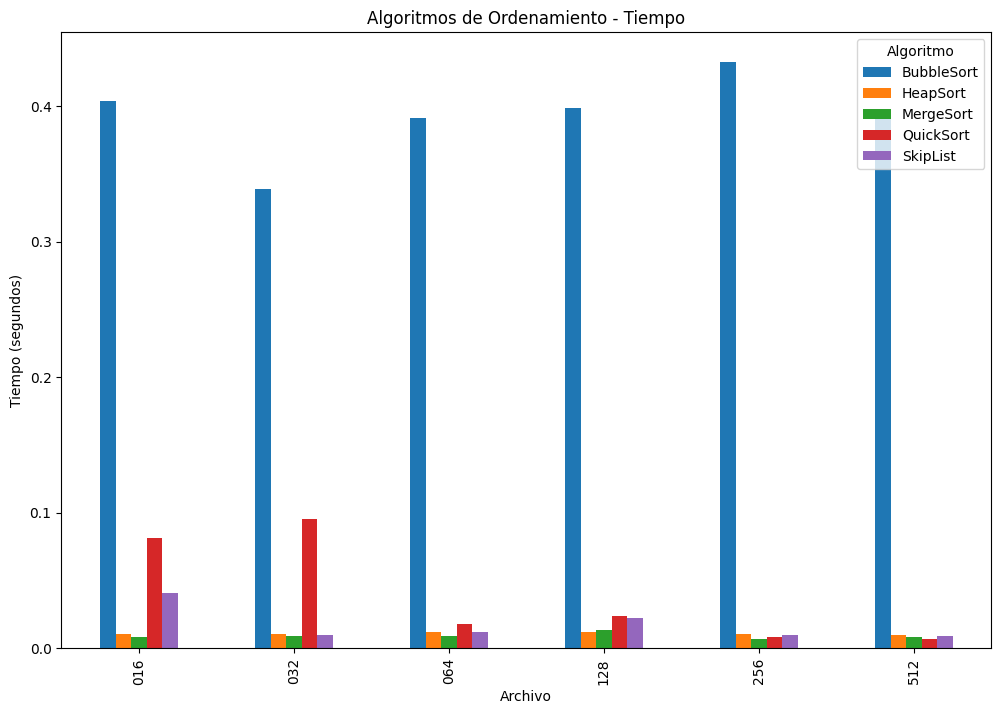

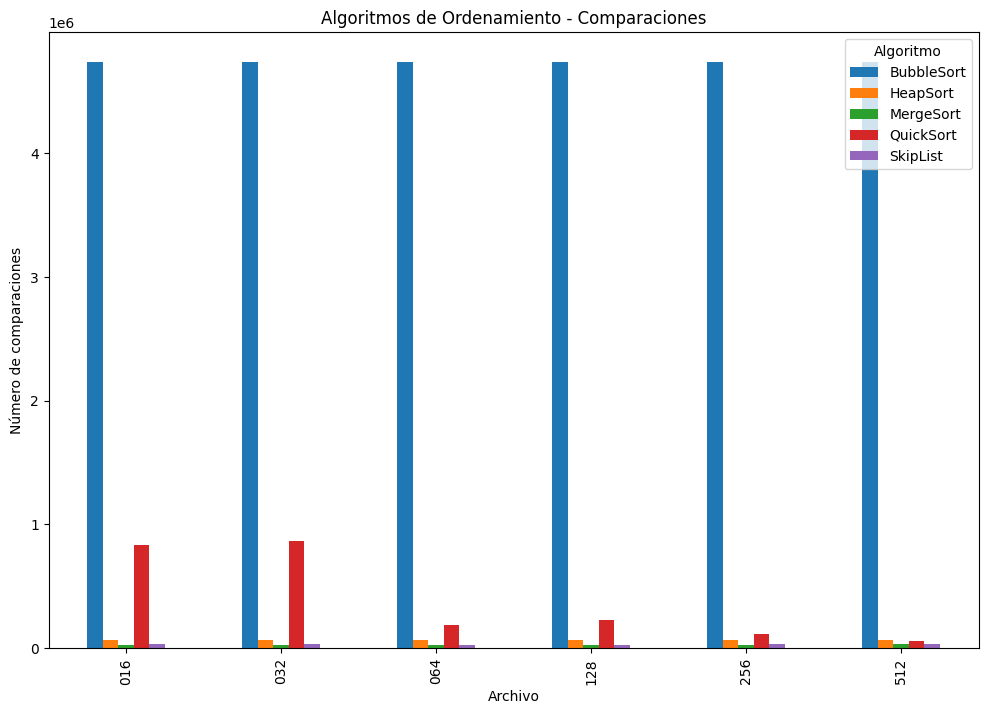

In [ ]:
# Ejecutamos la funcion
print("\nIniciandode algoritmos de ordenamiento...")
results_df = sort_algorithms(datos_json)

* Gráfico 1: Tiempo de ejecución
    * BubbleSort domina visualmente en todos los casos como el algoritmo más lento. Su complejidad O(n²) lo vuelve ineficiente incluso con listas de tamaño moderado (ej. ~0.4s frente a <0.02s de otros).

    * QuickSort es significativamente más rápido que BubbleSort, pero su tiempo disminuye conforme disminuye el desorden (probablemente porque elegiste pivote aleatorio o por patrones de los datos).

    * MergeSort, HeapSort y SkipList muestran tiempos de ejecución muy bajos y consistentes entre archivos, lo cual indica su estabilidad y buen rendimiento para listas medianas (~3,000 elementos).

    * SkipList, aunque más rápido que Bubble en órdenes de magnitud, es más lento que Heap y Merge, lo cual es esperable por su naturaleza probabilística y mayor sobrecarga de punteros.

    * Los algoritmos O(n log n) (MergeSort, HeapSort, QuickSort, SkipList) son mucho más eficientes. SkipList es competitivo, pero con tiempos ligeramente mayores debido a su estructura.



* Gráfico 2: Número de Comparaciones
    * BubbleSort nuevamente sobresale negativamente: realiza más de 4.7 millones de comparaciones por archivo, sin importar el nivel de desorden, lo que confirma su falta de adaptividad.

    * QuickSort empieza con muchas comparaciones (casos con p=016 y p=032), pero disminuye drásticamente a medida que el desorden disminuye (p=512), mostrando mejor adaptabilidad con la estrategia de pivote aleatorio.

    * MergeSort, HeapSort y SkipList mantienen un número de comparaciones mucho más bajo y estable. Merge y Heap están por debajo de las 70,000 comparaciones en todos los casos.

    * SkipList, aunque eficiente, tiene variabilidad mayor a HeapSort y MergeSort, lo que sugiere una mayor sensibilidad al orden de entrada (por su naturaleza probabilística).

    * En términos de comparaciones, BubbleSort es el peor, QuickSort mejora gracias a pivote aleatorio, y SkipList se comporta bien aunque con más variabilidad que MergeSort y HeapSort.



In [ ]:
# Generar tablas pivote
pivot_comp = results_df.pivot(index='Archivo', columns='Algoritmo', values='Comparaciones')
pivot_time = results_df.pivot(index='Archivo', columns='Algoritmo', values='Tiempos')


In [ ]:
# Mostrar tablas de resumen
print("\nResumen de comparaciones:")
display(pivot_comp)


Resumen de comparaciones:


Algoritmo,BubbleSort,HeapSort,MergeSort,QuickSort,SkipList
Archivo,,,,,
016,4741660,64787,22813,830673,35753
032,4741660,64715,23799,867552,32790
064,4741660,64654,25934,185760,29139
128,4741660,64536,27996,227177,29902
256,4741660,64315,29032,111610,30551
512,4741660,63936,30263,60118,31721


In [ ]:
print("\nResumen de tiempos de ejecución (segundos):")
display(pivot_time)


Resumen de tiempos de ejecución (segundos):


Algoritmo,BubbleSort,HeapSort,MergeSort,QuickSort,SkipList
Archivo,,,,,
016,0.404151,0.010510,0.008000,0.081106,0.040640
032,0.339089,0.010527,0.008690,0.095062,0.010010
064,0.390928,0.011996,0.009044,0.017555,0.011711
128,0.398614,0.012040,0.013554,0.023685,0.022587
256,0.432929,0.010526,0.007000,0.008595,0.009514
512,0.391433,0.010008,0.008010,0.006521,0.009139


In [ ]:
# Guardar resultados en CSV
results_df.to_csv('resultados_ordenamiento.csv', index=False)
print("\nResultados guardados en 'resultados_ordenamiento.csv'")


Resultados guardados en 'resultados_ordenamiento.csv'


## ✅ Análisis de los resultados

### Comparación de número de comparaciones

Analizamos los resultados de las comparaciones realizadas por cada algoritmo:

- **Bubblesort**: Realiza mayores comparaciones que los demás algoritmos debido a su complejidad O(n²).
- **Quicksort**: Generalmente eficiente en número de comparaciones, con complejidad promedio O(n log n).
- **Mergesort**: Consistentemente eficiente en comparaciones, con complejidad O(n log n).
- **Heapsort**: También con complejidad O(n log n), pero con un factor constante mayor que Quicksort o Mergesort.
- **SkipList**: Estructura probabilística que ofrece complejidad promedio O(n log n) para ordenamiento (Pugh 1990).


### ✅ Comparación de tiempos de ejecución

Además del número de comparaciones, el tiempo de ejecución también depende de otros factores como el manejo de memoria y la implementación específica (como vimos en la practica anterior):

- **Bubblesort**: Es el más lento para conjuntos de datos grandes.
- **Quicksort**:  Generalmente el más rápido en la práctica para conjuntos aleatorios (Cormen et al. 2022).
- **Mergesort**: Estable en tiempos de ejecución independientemente del orden inicial.
- **Heapsort**: Generalmente más lento que Quicksort, pero con garantías de peor caso.
- **SkipList**: Interesante alternativa con beneficios en ciertos escenarios específicos (Pugh 1990).

### ✅ Conclusiones

Los resultados confirman la teoría de complejidad de estos algoritmos. La elección del algoritmo óptimo dependerá del contexto específico:

- Para conjuntos de datos pequeños o casi ordenados, algoritmos simples pueden ser suficientes (Cook y Kim 1980).
- Para conjuntos grandes, los algoritmos O(n log n) son claramente superiores.
- Mergesort es preferible cuando se necesita estabilidad.
- Quicksort suele ser la opción más rápida en promedio para datos aleatorios.

Los algoritmos adaptativos también pueden jugar un papel importante dependiendo de la estructura de los datos (Estivill-Castro y Wood 1992). El análisis presentado permite tomar decisiones en la selección del método de ordenamiento adecuado según el caso de uso.

## 📚 Referencias

* Cook, Curtis R, y Do Jin Kim. 1980. "Best Sorting Algorithm for Nearly Sorted Lists." Communications of the ACM 23 (11): 620–24.

* Cormen, Thomas H, Charles E Leiserson, Ronald L Rivest, y Clifford Stein. 2022. Introduction to Algorithms. MIT Press.

* Estivill-Castro, Vladmir, y Derick Wood. 1992. "A survey of adaptive sorting algorithms." ACM Computing Surveys (CSUR) 24 (4): 441–76.

* Pugh, William. 1990. "Skip Lists: A Probabilistic Alternative to Balanced Trees." Commun. ACM 33 (6): 668–76. https://doi.org/10.1145/78973.78977.